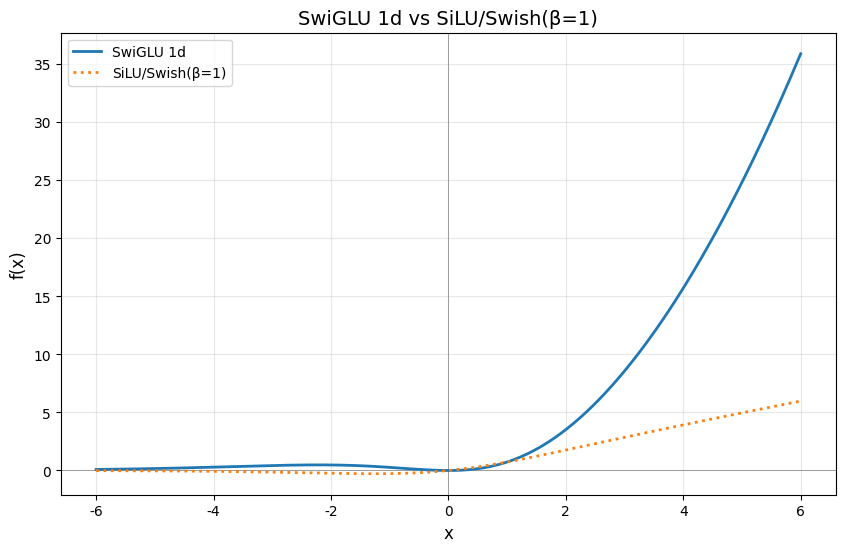

数值对比:

x = -3:
  right SwiGLU: 0.426833

x = -1:
  right SwiGLU: 0.268941

x = 0:
  right SwiGLU: 0.000000

x = 1:
  right SwiGLU: 0.731059

x = 3:
  right SwiGLU: 8.573168

标准神经网络中使用的SwiGLU层示例:
输入形状: torch.Size([32, 128]), 输出形状: torch.Size([32, 128])


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# from matplotlib import font_manager
# names = sorted({f.name for f in font_manager.fontManager.ttflist})
# print(names[:50])         # 看看前50个

# 配置中文字体（按顺序匹配系统中存在的字体，macOS/Windows/Linux通用）
plt.rcParams['font.sans-serif'] = [
    'DejaVu Sans',  # macOS 自带
]
# 解决负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False


def swiglu_1d(x, beta=1.0):
    """
    正确的1D SwiGLU实现
    原始SwiGLU公式: SwiGLU(x) = (x · W1 + b1) ⊙ Swish(x · W2 + b2, beta)
    这里是简化的1D版本，直接将输入作为两个分支的输入进行运算
    标准SwiGLU在GLU的基础上将sigmoid门替换为Swish函数
    """
    # 1D版本简化实现：将输入作为两个分支，一个分支过Swish，一个分支直接，然后相乘
    # 对应标准实现中两个线性变换权重都为1，偏置都为0的情况
    return x * F.silu(beta * x)  # F.silu就是Swish(beta=1)，这里乘以beta实现带参数的版本



xs = torch.linspace(-6, 6, 1000)
ys_correct = swiglu_1d(xs)
ys_silu = F.silu(xs)

plt.figure(figsize=(10, 6))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.plot(xs.numpy(), ys_correct.numpy(), label='SwiGLU 1d', linewidth=2)
plt.plot(xs.numpy(), ys_silu.numpy(), label='SiLU/Swish(β=1)', linewidth=2, linestyle=':')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('SwiGLU 1d vs SiLU/Swish(β=1)', fontsize=14)
plt.show()

# 打印关键点数值对比
print("数值对比:")
for x_val in [-3, -1, 0, 1, 3]:
    t = torch.tensor(x_val)
    print(f"\nx = {x_val}:")
    print(f"  right SwiGLU: {swiglu_1d(t).item():.6f}")

# 标准的SwiGLU层实现（神经网络中使用的版本）
print("\n" + "="*50)
print("标准神经网络中使用的SwiGLU层示例:")
class SwiGLU(torch.nn.Module):
    def __init__(self, hidden_dim, beta=1.0, use_bias=True):
        super().__init__()
        self.w1 = torch.nn.Linear(hidden_dim, hidden_dim, bias=use_bias)
        self.w2 = torch.nn.Linear(hidden_dim, hidden_dim, bias=use_bias)
        self.beta = beta
        
    def forward(self, x):
        return self.w1(x) * F.silu(self.beta * self.w2(x))

# 示例用法
d_model = 128
swiglu_layer = SwiGLU(d_model)
test_input = torch.randn(32, d_model)  # (batch_size, hidden_dim)
output = swiglu_layer(test_input)
print(f"输入形状: {test_input.shape}, 输出形状: {output.shape}")


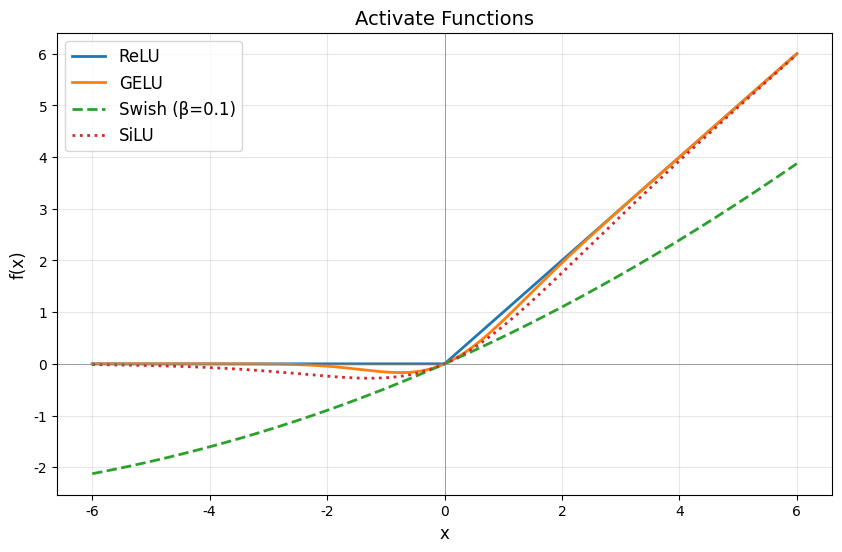

各激活函数在关键点的值:

x = -3:
  ReLU: 0.0000
  GELU: -0.0040
  Swish: -0.1423
  SiLU: -0.1423

x = -1:
  ReLU: 0.0000
  GELU: -0.1587
  Swish: -0.2689
  SiLU: -0.2689

x = 0:
  ReLU: 0.0000
  GELU: 0.0000
  Swish: 0.0000
  SiLU: 0.0000

x = 1:
  ReLU: 1.0000
  GELU: 0.8413
  Swish: 0.7311
  SiLU: 0.7311

x = 3:
  ReLU: 3.0000
  GELU: 2.9960
  Swish: 2.8577
  SiLU: 2.8577


In [2]:
import torch
import matplotlib.pyplot as plt

# 定义激活函数
def relu(x):
    """ReLU激活函数: f(x) = max(0, x)"""
    return torch.maximum(torch.tensor(0.0), x)

def gelu(x):
    """GELU激活函数: f(x) = x * Φ(x), Φ是标准高斯分布的累积分布函数"""
    return x * 0.5 * (1.0 + torch.erf(x / torch.sqrt(torch.tensor(2.0))))

def swish(x, beta=1.0):
    """Swish激活函数: f(x) = x * sigmoid(beta * x)"""
    return x * torch.sigmoid(beta * x)

def silu(x):
    """SiLU激活函数: f(x) = x * sigmoid(x), 是Swish在beta=1时的特例"""
    return x * torch.sigmoid(x)

# 生成x轴数据
x = torch.linspace(-6, 6, 1000)

# 计算各激活函数的输出
y_relu = relu(x)
y_gelu = gelu(x)
y_swish = swish(x, beta=0.1)  # 这里使用β=0.1的Swish作为示例
y_silu = silu(x)

# 创建画布
plt.figure(figsize=(10, 6))

# 绘制各函数曲线
plt.plot(x.numpy(), y_relu.numpy(), label='ReLU', linewidth=2)
plt.plot(x.numpy(), y_gelu.numpy(), label='GELU', linewidth=2)
plt.plot(x.numpy(), y_swish.numpy(), label='Swish (β=0.1)', linewidth=2, linestyle='--')
plt.plot(x.numpy(), y_silu.numpy(), label='SiLU', linewidth=2, linestyle=':')

# 设置坐标轴和网格
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)

# 设置图例和标题
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Activate Functions', fontsize=14)
plt.legend(fontsize=12)

# 显示图像
plt.show()

# 打印各函数在几个关键点的值
print("各激活函数在关键点的值:")
for point in [-3, -1, 0, 1, 3]:
    print(f"\nx = {point}:")
    print(f"  ReLU: {relu(torch.tensor(point)).item():.4f}")
    print(f"  GELU: {gelu(torch.tensor(point)).item():.4f}")
    print(f"  Swish: {swish(torch.tensor(point)).item():.4f}")
    print(f"  SiLU: {silu(torch.tensor(point)).item():.4f}")
